In [35]:
# Global Minimum Variance (GMV) Portfolio
# Using 10 Indian Stocks with Yahoo Finance
# ============================================================


!pip install yfinance scipy --quiet


# Import Libraries ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

plt.style.use("ggplot")

In [36]:
# Select Same 10 Indian Stocks ================================


stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "LT.NS",
    "ITC.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "HINDUNILVR.NS"
]


# Download Historical Prices  ==============================

prices = yf.download(
    stocks,
    start="2019-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

print("Price Data")
display(prices.head())


Price Data


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2019-01-01,280.425415,496.185852,1591.314209,350.957031,541.725891,196.502701,1283.006226,496.196320,271.551178,1561.000244
2019-01-02,274.413177,491.658569,1576.736206,351.777130,544.983948,195.043030,1268.413696,489.733917,266.384796,1577.817993
2019-01-03,275.159241,487.800995,1580.093872,350.474609,545.065491,193.826584,1241.274658,483.691925,263.846954,1558.662354
2019-01-04,283.014648,489.106140,1574.174194,352.356049,538.467712,195.286301,1235.090576,486.303406,269.783722,1539.711670
2019-01-07,285.208923,489.845215,1577.045654,354.768097,547.142822,195.772842,1231.308838,489.003540,268.560089,1556.980347


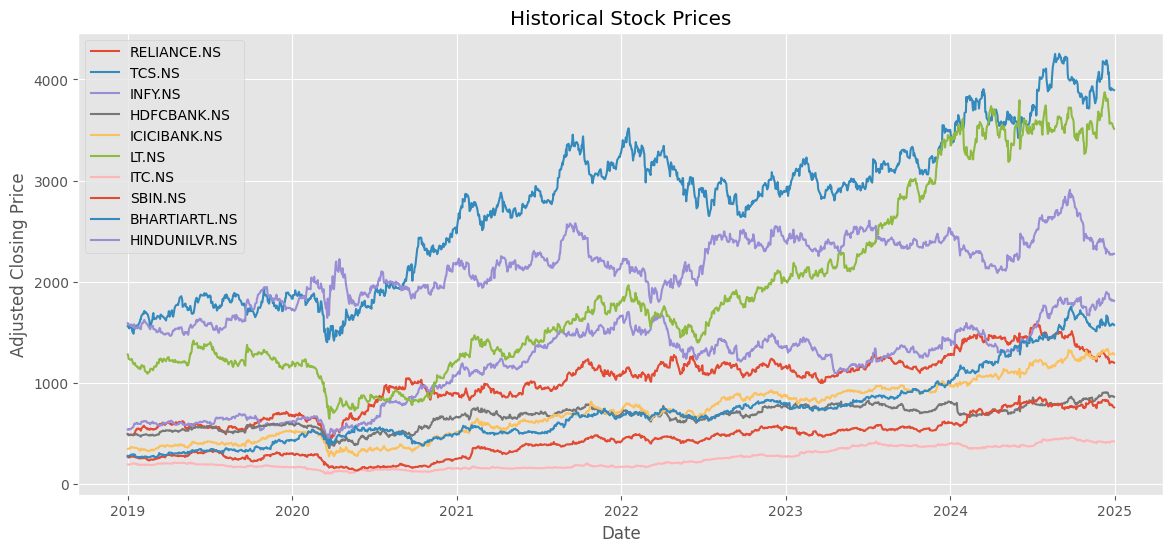

In [37]:
# Plot Stock Prices ==============================


plt.figure(figsize=(14,6))

for stock in stocks:
    plt.plot(prices.index, prices[stock], label=stock)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.show()

In [38]:
# Daily Returns ==============================


returns = prices.pct_change().dropna()

print("\nDaily Returns")
display(returns.head())


# Annual Covariance Matrix ==============================


cov_matrix = returns.cov() * 252

print("\nAnnual Covariance Matrix")
display(cov_matrix)



Daily Returns


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2019-01-02,-0.021440,-0.009124,-0.009161,0.002337,0.006014,-0.007428,-0.011374,-0.013024,-0.019025,0.010774
2019-01-03,0.002719,-0.007846,0.002130,-0.003703,0.000150,-0.006237,-0.021396,-0.012337,-0.009527,-0.012141
2019-01-04,0.028549,0.002676,-0.003746,0.005368,-0.012105,0.007531,-0.004982,0.005399,0.022501,-0.012158
2019-01-07,0.007753,0.001511,0.001824,0.006845,0.016111,0.002491,-0.003062,0.005552,-0.004536,0.011216
2019-01-08,0.013233,-0.008323,-0.007900,0.033859,-0.002457,0.009231,-0.001156,-0.000090,0.030375,-0.002292



Annual Covariance Matrix


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Ticker,,,,,,,,,,
BHARTIARTL.NS,0.088316,0.024906,0.015105,0.031748,0.021425,0.019496,0.028550,0.025982,0.033553,0.017083
HDFCBANK.NS,0.024906,0.068510,0.016077,0.050795,0.022487,0.019487,0.037104,0.031928,0.044639,0.017529
HINDUNILVR.NS,0.015105,0.016077,0.053762,0.018305,0.018281,0.016099,0.016611,0.020899,0.015332,0.016566
ICICIBANK.NS,0.031748,0.050795,0.018305,0.097401,0.026491,0.026219,0.046958,0.037386,0.068442,0.021375
INFY.NS,0.021425,0.022487,0.018281,0.026491,0.077578,0.014684,0.023111,0.025231,0.022667,0.043415
ITC.NS,0.019496,0.019487,0.016099,0.026219,0.014684,0.062973,0.024818,0.020691,0.033164,0.013243
LT.NS,0.028550,0.037104,0.016611,0.046958,0.023111,0.024818,0.079487,0.031836,0.050512,0.019002
RELIANCE.NS,0.025982,0.031928,0.020899,0.037386,0.025231,0.020691,0.031836,0.085900,0.039708,0.024489
SBIN.NS,0.033553,0.044639,0.015332,0.068442,0.022667,0.033164,0.050512,0.039708,0.110994,0.019378


In [39]:
# Portfolio Volatility Function ==============================


def portfolio_volatility(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

# Objective Function
# Minimize Portfolio Volatility


def objective(weights):

    return portfolio_volatility(weights)


# Optimization Setup ==============================


n_assets = len(stocks)

initial_weights = np.ones(n_assets) / n_assets

constraints = ({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
})

bounds = tuple((0,1) for _ in range(n_assets))


# Run Optimization ==============================


result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

weights = result.x


# Portfolio Allocation ==============================


portfolio = pd.DataFrame({
    "Stock": stocks,
    "Weight": weights
})

portfolio["Weight (%)"] = portfolio["Weight"] * 100

portfolio = portfolio.sort_values(
    by="Weight",
    ascending=False
)

print("\nGlobal Minimum Variance Portfolio")
display(portfolio)



Global Minimum Variance Portfolio


,Stock,Weight,Weight (%)
2,INFY.NS,2.588857e-01,2.588857e+01
9,HINDUNILVR.NS,2.073710e-01,2.073710e+01
5,LT.NS,1.980818e-01,1.980818e+01
1,TCS.NS,1.243430e-01,1.243430e+01
0,RELIANCE.NS,9.982776e-02,9.982776e+00
6,ITC.NS,4.649561e-02,4.649561e+00
4,ICICIBANK.NS,3.505027e-02,3.505027e+00
7,SBIN.NS,2.994499e-02,2.994499e+00
8,BHARTIARTL.NS,4.119968e-18,4.119968e-16
3,HDFCBANK.NS,0.000000e+00,0.000000e+00


In [45]:
# Portfolio Statistics ==============================


portfolio_vol = portfolio_volatility(weights)

equal_weights = np.ones(n_assets) / n_assets

equal_weight_vol = portfolio_volatility(equal_weights)


print("GLOBAL MINIMUM VARIANCE PORTFOLIO")
print("="*80)
print(f"Minimum Annual Volatility : {portfolio_vol:.2%}")
print(f"Equal Weight Volatility   : {equal_weight_vol:.2%}")



GLOBAL MINIMUM VARIANCE PORTFOLIO
Minimum Annual Volatility : 16.15%
Equal Weight Volatility   : 17.91%


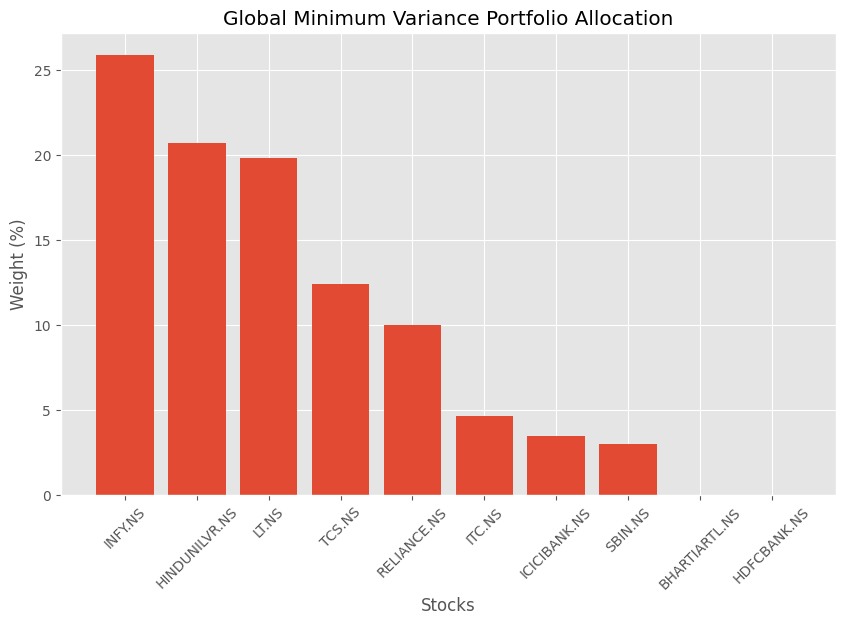

In [46]:
# Plot Portfolio Allocation ==============================


plt.figure(figsize=(10,6))

plt.bar(
    portfolio["Stock"],
    portfolio["Weight (%)"]
)

plt.title("Global Minimum Variance Portfolio Allocation")
plt.xlabel("Stocks")
plt.ylabel("Weight (%)")
plt.xticks(rotation=45)

plt.show()


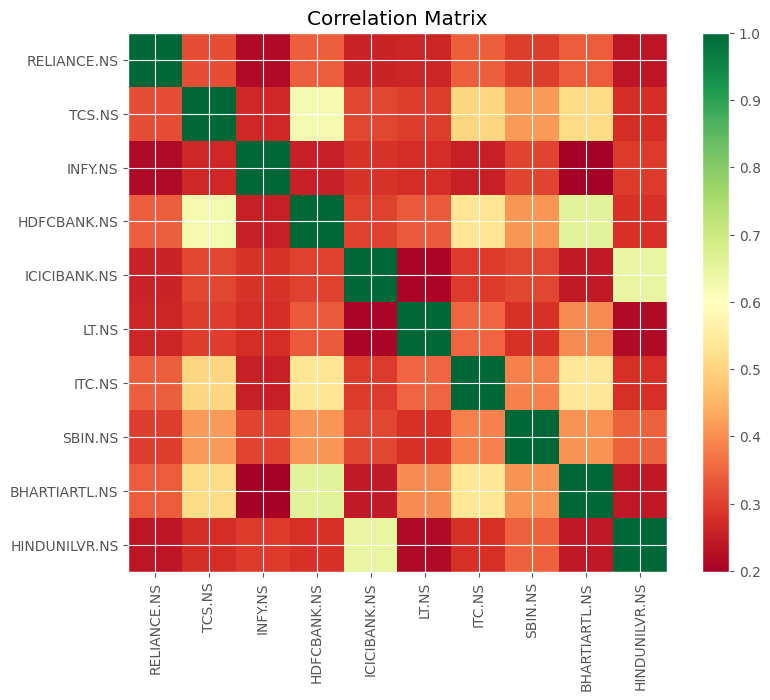

In [42]:
# Correlation Matrix ==============================


corr = returns.corr()

plt.figure(figsize=(9,7))

plt.imshow(
    corr,
    cmap="RdYlGn",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(stocks)),
    stocks,
    rotation=90
)

plt.yticks(
    range(len(stocks)),
    stocks
)

plt.title("Correlation Matrix")

plt.show()




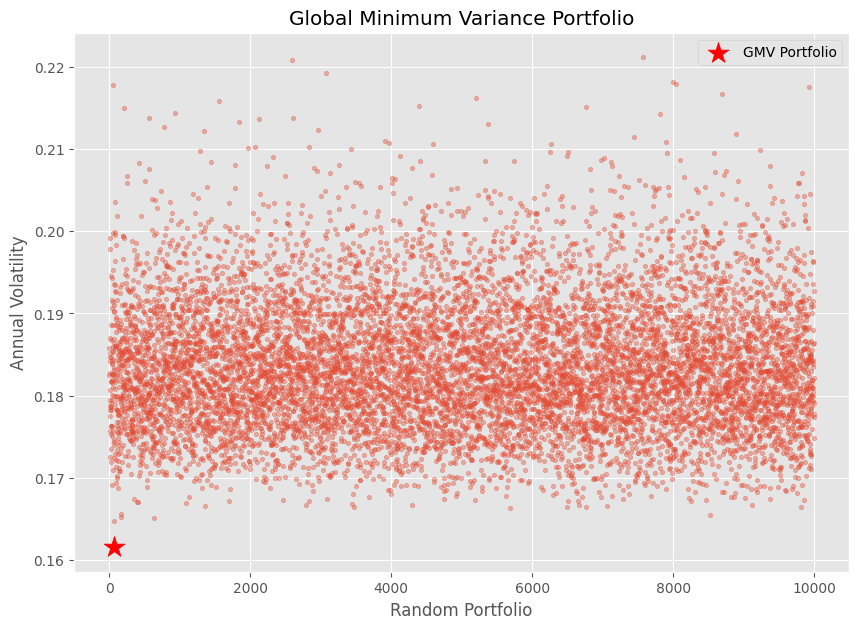

In [43]:
# Monte Carlo Random Portfolios  ==============================


n_portfolios = 10000

volatility = []

all_weights = []

for _ in range(n_portfolios):

    w = np.random.random(n_assets)

    w /= np.sum(w)

    all_weights.append(w)

    vol = portfolio_volatility(w)

    volatility.append(vol)

volatility = np.array(volatility)


# Plot Minimum Variance Portfolio ==============================


plt.figure(figsize=(10,7))

plt.scatter(
    range(n_portfolios),
    volatility,
    alpha=0.4,
    s=10
)

plt.scatter(
    np.argmin(volatility),
    portfolio_vol,
    color="red",
    s=250,
    marker="*",
    label="GMV Portfolio"
)

plt.xlabel("Random Portfolio")
plt.ylabel("Annual Volatility")
plt.title("Global Minimum Variance Portfolio")

plt.legend()

plt.show()

In [47]:

# Expected Portfolio Return ==============================


expected_returns = returns.mean() * 252

portfolio_return = np.dot(
    weights,
    expected_returns
)

risk_free_rate = 0.06

portfolio_sharpe = (
    portfolio_return - risk_free_rate
) / portfolio_vol


# Portfolio Statistics ==============================



print("GLOBAL MINIMUM VARIANCE PORTFOLIO")
print("="*90)

print(f"Expected Annual Return : {portfolio_return:.2%}")
print(f"Annual Volatility      : {portfolio_vol:.2%}")
print(f"Sharpe Ratio           : {portfolio_sharpe:.3f}")


GLOBAL MINIMUM VARIANCE PORTFOLIO
Expected Annual Return : 16.72%
Annual Volatility      : 16.15%
Sharpe Ratio           : 0.664
